## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE
import json
import joblib
from datetime import datetime

# Configure visualization settings
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

print('✅ Imports ready for supervised learning comparison.')
print(f'⏰ Training session started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Imports ready for supervised learning comparison.
⏰ Training session started at: 2025-09-06 22:00:07


## 2. Load Dataset

In [2]:
print('📂 LOADING ENGINEERED FEATURES DATASET')
print('=' * 60)

# Create results directories
model_results_dir = Path('../results/model_training')
model_save_dir = Path('../models')
model_results_dir.mkdir(parents=True, exist_ok=True)
model_save_dir.mkdir(parents=True, exist_ok=True)

# Define required files and check availability
required_files = {
    'selected_features': Path('../data/selected_features.csv'),
    'target_classes': Path('../data/target_classes.json')
}

missing_files = []
for file_type, file_path in required_files.items():
    if not file_path.exists():
        missing_files.append(f'{file_type}: {file_path}')

if missing_files:
    print('❌ Required files missing:')
    for missing in missing_files:
        print(f'   • {missing}')
    raise FileNotFoundError('Please run previous notebooks in sequence: 01_Data_Loading → 02_Data_Preprocessing → 03_Feature_Engineering')

# Load engineered features dataset
print('📊 Loading selected features dataset...')
df = pd.read_csv(required_files['selected_features'])

# Load target class information
with open(required_files['target_classes'], 'r') as f:
    target_classes = json.load(f)

print(f'✅ Dataset loaded successfully!')
print(f'📊 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'🎯 Target column: NObeyesdad_encoded')
print(f'📋 Target classes: {len(target_classes)} classes')

# Display dataset info
print(f'\n📋 DATASET INFORMATION:')
print(f'   • Total samples: {len(df):,}')
print(f'   • Total features: {df.shape[1] - 1}')  # -1 for target column
print(f'   • Target classes: {sorted(df["NObeyesdad_encoded"].unique())}')

# Display feature types
feature_cols = [col for col in df.columns if col != 'NObeyesdad_encoded']
numerical_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f'   • Numerical features: {len(numerical_features)}')
print(f'   • Categorical features: {len(categorical_features)}')

if categorical_features:
    print(f'   • Categorical features detected: {categorical_features[:5]}{"..." if len(categorical_features) > 5 else ""}')

# Target distribution
target_dist = df['NObeyesdad_encoded'].value_counts().sort_index()
print(f'\n📊 TARGET DISTRIBUTION:')
for class_idx, count in target_dist.items():
    class_name = target_classes[str(int(class_idx))] if str(int(class_idx)) in target_classes else f'Class_{class_idx}'
    percentage = count / len(df) * 100
    print(f'   • {class_name}: {count:,} samples ({percentage:.1f}%)')

print(f'\n✅ Data loading complete - Ready for model training!')

📂 LOADING ENGINEERED FEATURES DATASET
📊 Loading selected features dataset...
✅ Dataset loaded successfully!
📊 Dataset shape: 20,758 rows × 26 columns
🎯 Target column: NObeyesdad_encoded
📋 Target classes: 4 classes

📋 DATASET INFORMATION:
   • Total samples: 20,758
   • Total features: 25
   • Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
   • Numerical features: 17
   • Categorical features: 8
   • Categorical features detected: ['Gender', 'Gender_Female', 'Gender_Male', 'family_history_with_overweight', 'family_history_with_overweight_yes']...

📊 TARGET DISTRIBUTION:
   • Class_0: 2,523 samples (12.2%)
   • Class_1: 3,082 samples (14.8%)
   • Class_2: 2,910 samples (14.0%)
   • Class_3: 3,248 samples (15.6%)
   • Class_4: 4,046 samples (19.5%)
   • Class_5: 2,427 samples (11.7%)
   • Class_6: 2,522 samples (12.1%)

✅ Data loading complete - Ready for model training!


## 3. Train-Test Split & Data Preparation

In [3]:
def prepare_xy(df: pd.DataFrame, target_col='NObeyesdad_encoded'):
    """Prepare features and target from dataframe"""
    if target_col not in df.columns:
        raise KeyError(f'Target column {target_col} not found in dataframe.')
    y = df[target_col].copy()
    X = df.drop(columns=[target_col])
    return X, y

# Prepare features and target
X, y = prepare_xy(df)

print(f'Dataset shape: {X.shape}')
print(f'Target distribution: {y.value_counts().sort_index().to_dict()}')

# Handle data quality issues
missing_values = X.isnull().sum().sum()
if missing_values > 0:
    print(f'⚠️ Handling {missing_values} missing values...')
    X = X.fillna(X.median())

# Convert boolean columns to numeric
bool_cols = X.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Handle any remaining non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    print(f'⚠️ Encoding {len(non_numeric_cols)} non-numeric columns...')
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col in non_numeric_cols:
        X[col] = le.fit_transform(X[col])

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Further split training for validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print(f'Training set: {X_train_final.shape}')
print(f'Validation set: {X_val.shape}')
print(f'Test set: {X_test.shape}')

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train_final)

print(f'After SMOTE: {X_train_balanced.shape}')
print(f'Class balance achieved: {pd.Series(y_train_balanced).value_counts().nunique() == 1 if pd.Series(y_train_balanced).value_counts().std() < 1 else "Improved"}')

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_balanced_scaled = scaler.transform(X_train_balanced)

feature_names = X.columns.tolist()
print(f'✅ Data preparation complete with {len(feature_names)} features.')

Dataset shape: (20758, 25)
Target distribution: {0: 2523, 1: 3082, 2: 2910, 3: 3248, 4: 4046, 5: 2427, 6: 2522}
⚠️ Encoding 4 non-numeric columns...
Training set: (13284, 25)
Validation set: (3322, 25)
Test set: (4152, 25)
After SMOTE: (18130, 25)
Class balance achieved: True
✅ Data preparation complete with 25 features.
After SMOTE: (18130, 25)
Class balance achieved: True
✅ Data preparation complete with 25 features.


## 4. Model Definitions & Evaluation Function

In [4]:
# Define the 4 models for comparison
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0,
        penalty='l2',
        solver='lbfgs',
        multi_class='multinomial',
        max_iter=1000,
        random_state=42
    ),
    'Polynomial Regression (deg=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=0.1,
            penalty='l2',
            solver='lbfgs',
            multi_class='multinomial',
            max_iter=2000,
            random_state=42
        ))
    ]),
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softprob',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
}

def evaluate_models(X_train, X_val, X_test, y_train, y_val, y_test, 
                   X_train_balanced=None, y_train_balanced=None, use_scaling=None):
    """
    Evaluate all models with comprehensive metrics
    """
    results = {}
    trained_models = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, model in models.items():
        print(f'\n=== Training {name} ===')
        
        # Determine if scaling is needed
        needs_scaling = use_scaling or name in ['Logistic Regression', 'Polynomial Regression (deg=2)']
        
        # Select appropriate data
        if needs_scaling:
            if X_train_balanced is not None:
                train_X = X_train_balanced_scaled
                train_y = y_train_balanced
            else:
                train_X = X_train_scaled
                train_y = y_train
            val_X = X_val_scaled
            test_X = X_test_scaled
            cv_X = X_train_scaled
        else:
            if X_train_balanced is not None:
                train_X = X_train_balanced
                train_y = y_train_balanced
            else:
                train_X = X_train_final
                train_y = y_train
            val_X = X_val.values
            test_X = X_test.values
            cv_X = X_train_final.values
        
        # Train model
        model.fit(train_X, train_y)
        trained_models[name] = model
        
        # Cross-validation (on original training data to avoid data leakage)
        cv_scores = cross_val_score(model, cv_X, y_train_final, cv=cv, scoring='accuracy')
        
        # Predictions
        y_val_pred = model.predict(val_X)
        y_test_pred = model.predict(test_X)
        
        # Calculate metrics
        val_acc = accuracy_score(y_val, y_val_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        val_f1 = f1_score(y_val, y_val_pred, average='weighted')
        test_f1 = f1_score(y_test, y_test_pred, average='weighted')
        val_precision = precision_score(y_val, y_val_pred, average='weighted')
        test_precision = precision_score(y_test, y_test_pred, average='weighted')
        val_recall = recall_score(y_val, y_val_pred, average='weighted')
        test_recall = recall_score(y_test, y_test_pred, average='weighted')
        
        # Store results
        results[name] = {
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std(),
            'Val_Accuracy': val_acc,
            'Test_Accuracy': test_acc,
            'Val_F1': val_f1,
            'Test_F1': test_f1,
            'Val_Precision': val_precision,
            'Test_Precision': test_precision,
            'Val_Recall': val_recall,
            'Test_Recall': test_recall,
            'CV_Scores': cv_scores,
            'Predictions': y_test_pred
        }
        
        print(f'CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})')
        print(f'Test Accuracy: {test_acc:.4f}')
        print(f'Test F1-Score: {test_f1:.4f}')
        
        # Classification report
        print(f'\n{name} Classification Report:')
        target_names = [f'Class_{i}' for i in sorted(y_test.unique())]
        print(classification_report(y_test, y_test_pred, target_names=target_names, digits=3))
    
    # Create results DataFrame
    metrics_df = pd.DataFrame(results).T
    metrics_df = metrics_df.sort_values('Test_Accuracy', ascending=False)
    
    return metrics_df, trained_models, results

print('✅ Models and evaluation function ready.')
print(f'Models to compare: {list(models.keys())}')

✅ Models and evaluation function ready.
Models to compare: ['Random Forest', 'Logistic Regression', 'Polynomial Regression (deg=3)', 'XGBoost']


## 5. Model Training & Evaluation

In [5]:
# Train and evaluate all models
print('🚀 Starting Model Training & Evaluation')
print('=' * 60)

# Evaluate models with SMOTE-balanced training data
metrics_df, trained_models, detailed_results = evaluate_models(
    X_train_final, X_val, X_test, 
    y_train_final, y_val, y_test,
    X_train_balanced, y_train_balanced,
    use_scaling=False  # Let function decide based on model type
)

print('\n📊 Model Performance Summary:')
display(metrics_df[['CV_Mean', 'CV_Std', 'Test_Accuracy', 'Test_F1', 'Test_Precision', 'Test_Recall']].round(4))

# Identify best model
best_model_name = metrics_df.index[0]
best_model = trained_models[best_model_name]
best_metrics = detailed_results[best_model_name]

print(f'\n🏆 Best Model: {best_model_name}')
print(f'📊 Test Accuracy: {best_metrics["Test_Accuracy"]:.4f}')
print(f'📈 Test F1-Score: {best_metrics["Test_F1"]:.4f}')
print(f'🔄 CV Accuracy: {best_metrics["CV_Mean"]:.4f} (±{best_metrics["CV_Std"]:.4f})')

🚀 Starting Model Training & Evaluation

=== Training Random Forest ===
CV Accuracy: 0.8938 (±0.0036)
Test Accuracy: 0.8967
Test F1-Score: 0.8963

Random Forest Classification Report:
              precision    recall  f1-score   support

     Class_0      0.925     0.947     0.935       505
     Class_1      0.865     0.872     0.868       617
     Class_2      0.873     0.876     0.875       582
     Class_3      0.969     0.966     0.968       650
     Class_4      0.996     0.996     0.996       809
     Class_5      0.791     0.732     0.760       485
     Class_6      0.780     0.810     0.795       504

    accuracy                          0.897      4152
   macro avg      0.886     0.886     0.885      4152
weighted avg      0.896     0.897     0.896      4152


=== Training Logistic Regression ===
CV Accuracy: 0.8938 (±0.0036)
Test Accuracy: 0.8967
Test F1-Score: 0.8963

Random Forest Classification Report:
              precision    recall  f1-score   support

     Class_0   

,CV_Mean,CV_Std,Test_Accuracy,Test_F1,Test_Precision,Test_Recall
XGBoost,0.900181,0.001216,0.901734,0.901227,0.901518,0.901734
Random Forest,0.893782,0.003615,0.896676,0.896302,0.896294,0.896676
Polynomial Regression (deg=3),0.867509,0.006897,0.876686,0.876143,0.875969,0.876686
Logistic Regression,0.855842,0.001244,0.858382,0.857161,0.857354,0.858382



🏆 Best Model: XGBoost
📊 Test Accuracy: 0.9017
📈 Test F1-Score: 0.9012
🔄 CV Accuracy: 0.9002 (±0.0012)


## 6. Performance Visualization & Analysis

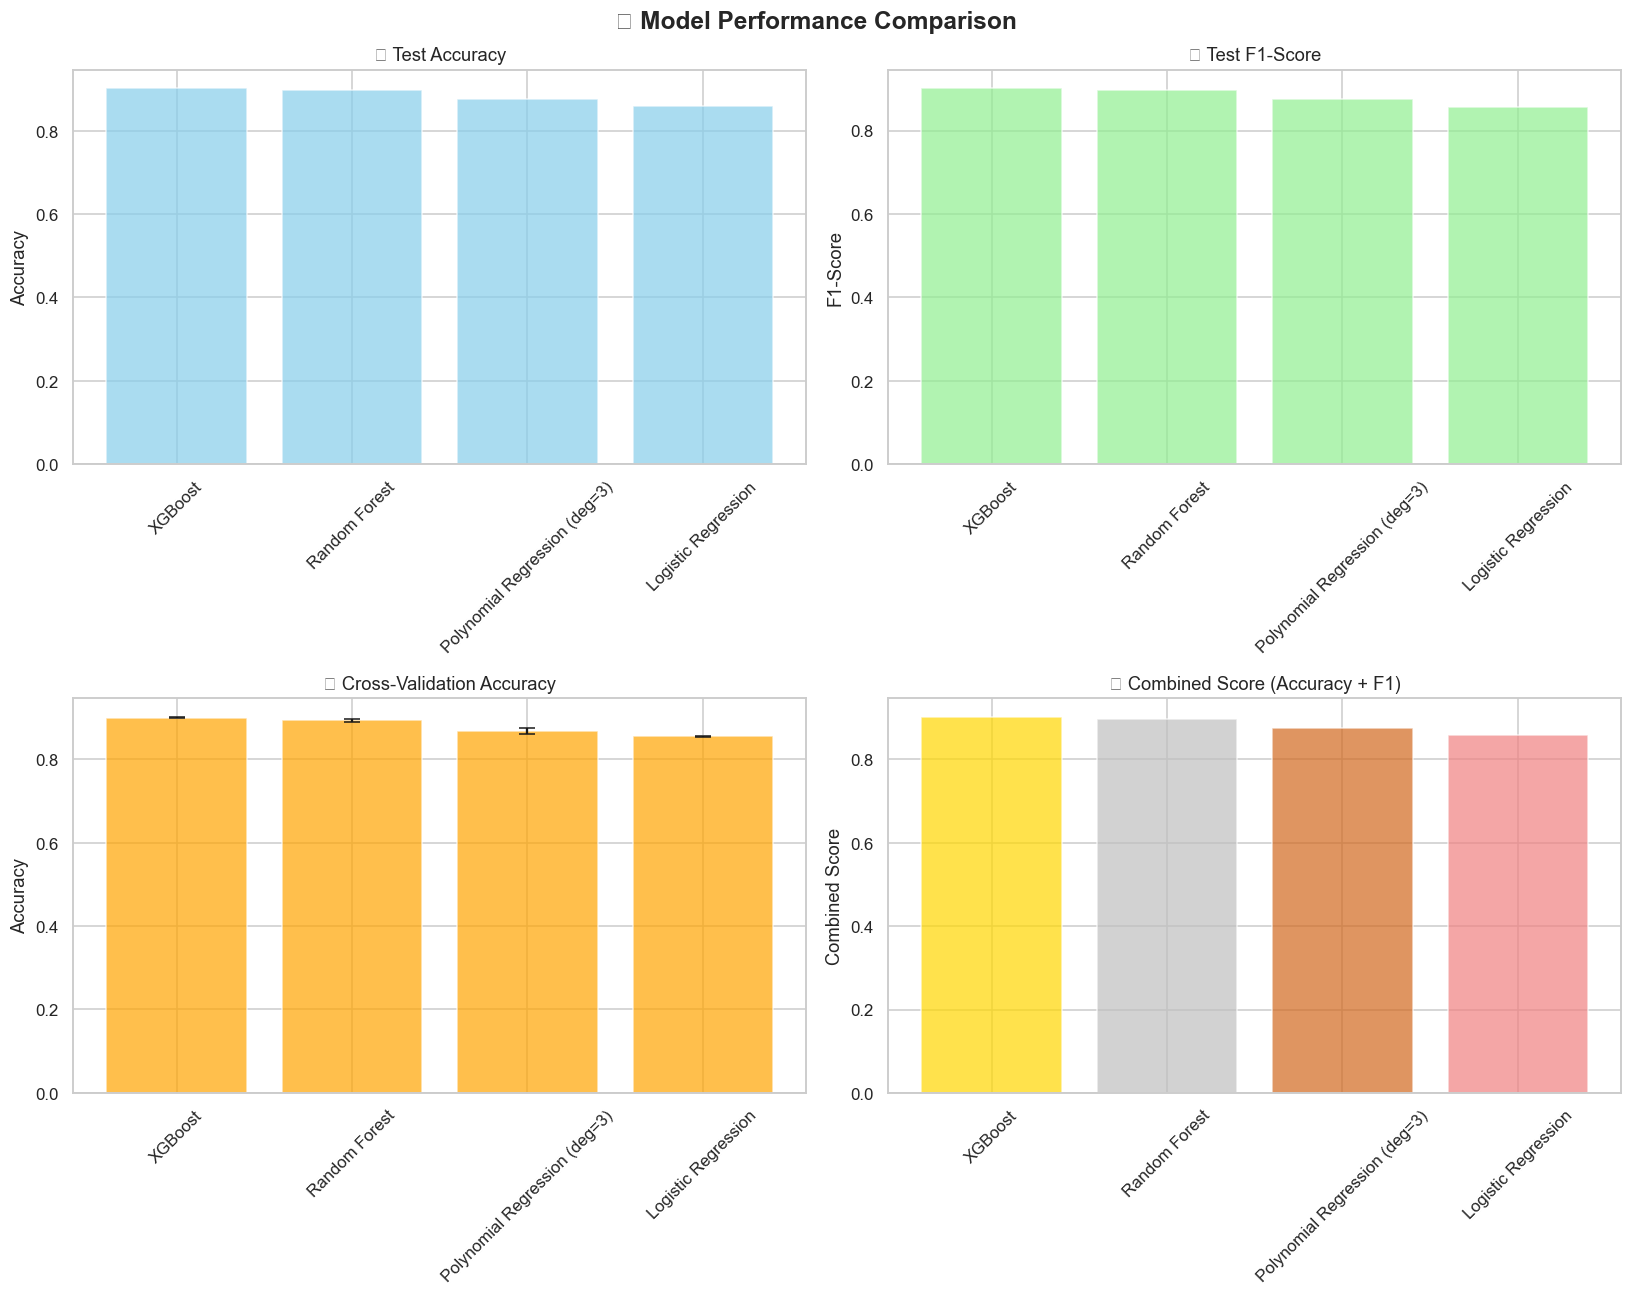

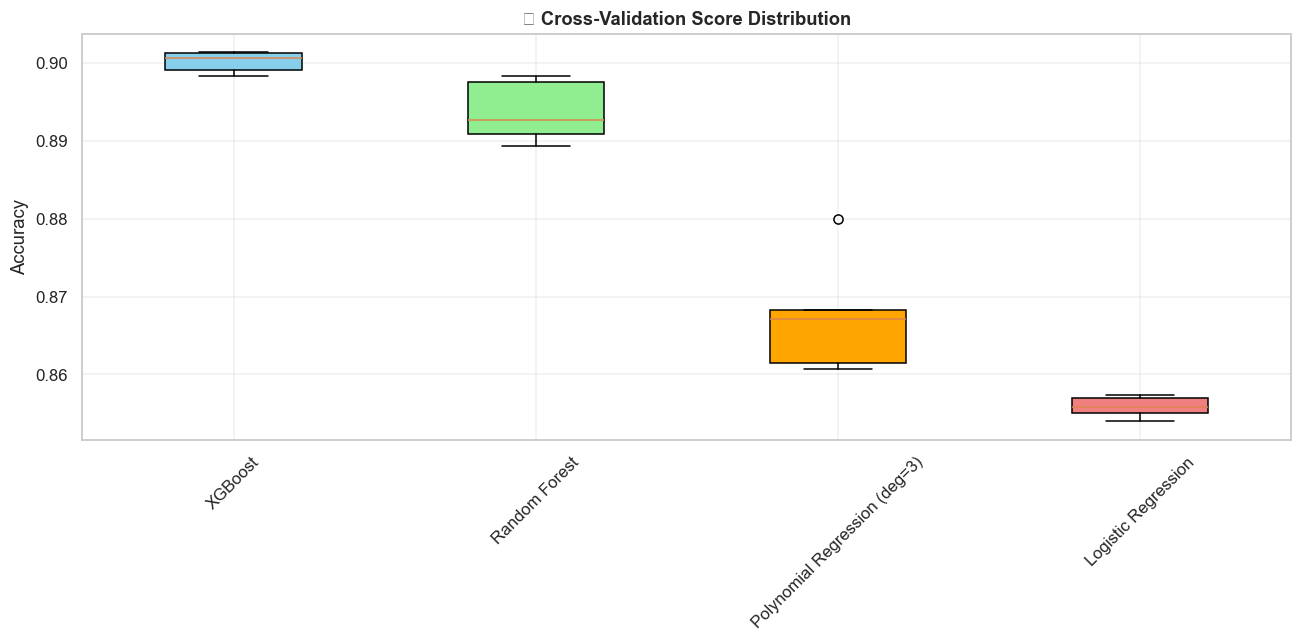

✅ Performance visualizations created!


In [6]:
# Performance comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 Model Performance Comparison', fontsize=16, fontweight='bold')

model_names = metrics_df.index.tolist()

# Test Accuracy
axes[0, 0].bar(model_names, metrics_df['Test_Accuracy'], alpha=0.7, color='skyblue')
axes[0, 0].set_title('✅ Test Accuracy')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Test F1-Score
axes[0, 1].bar(model_names, metrics_df['Test_F1'], alpha=0.7, color='lightgreen')
axes[0, 1].set_title('📈 Test F1-Score')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# Cross-Validation Accuracy with error bars
axes[1, 0].bar(model_names, metrics_df['CV_Mean'], 
               yerr=metrics_df['CV_Std'], capsize=5, alpha=0.7, color='orange')
axes[1, 0].set_title('🔄 Cross-Validation Accuracy')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].tick_params(axis='x', rotation=45)

# Combined metrics (Test Accuracy + F1)
combined_score = (metrics_df['Test_Accuracy'] + metrics_df['Test_F1']) / 2
colors = ['gold', 'silver', 'chocolate', 'lightcoral']
axes[1, 1].bar(model_names, combined_score, alpha=0.7, color=colors[:len(model_names)])
axes[1, 1].set_title('🏆 Combined Score (Accuracy + F1)')
axes[1, 1].set_ylabel('Combined Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Cross-validation score distribution
plt.figure(figsize=(12, 6))
cv_data = [detailed_results[model]['CV_Scores'] for model in model_names]
bp = plt.boxplot(cv_data, labels=model_names, patch_artist=True)
colors = ['skyblue', 'lightgreen', 'orange', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('📊 Cross-Validation Score Distribution', fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✅ Performance visualizations created!')


## 7. Confusion Matrix Analysis

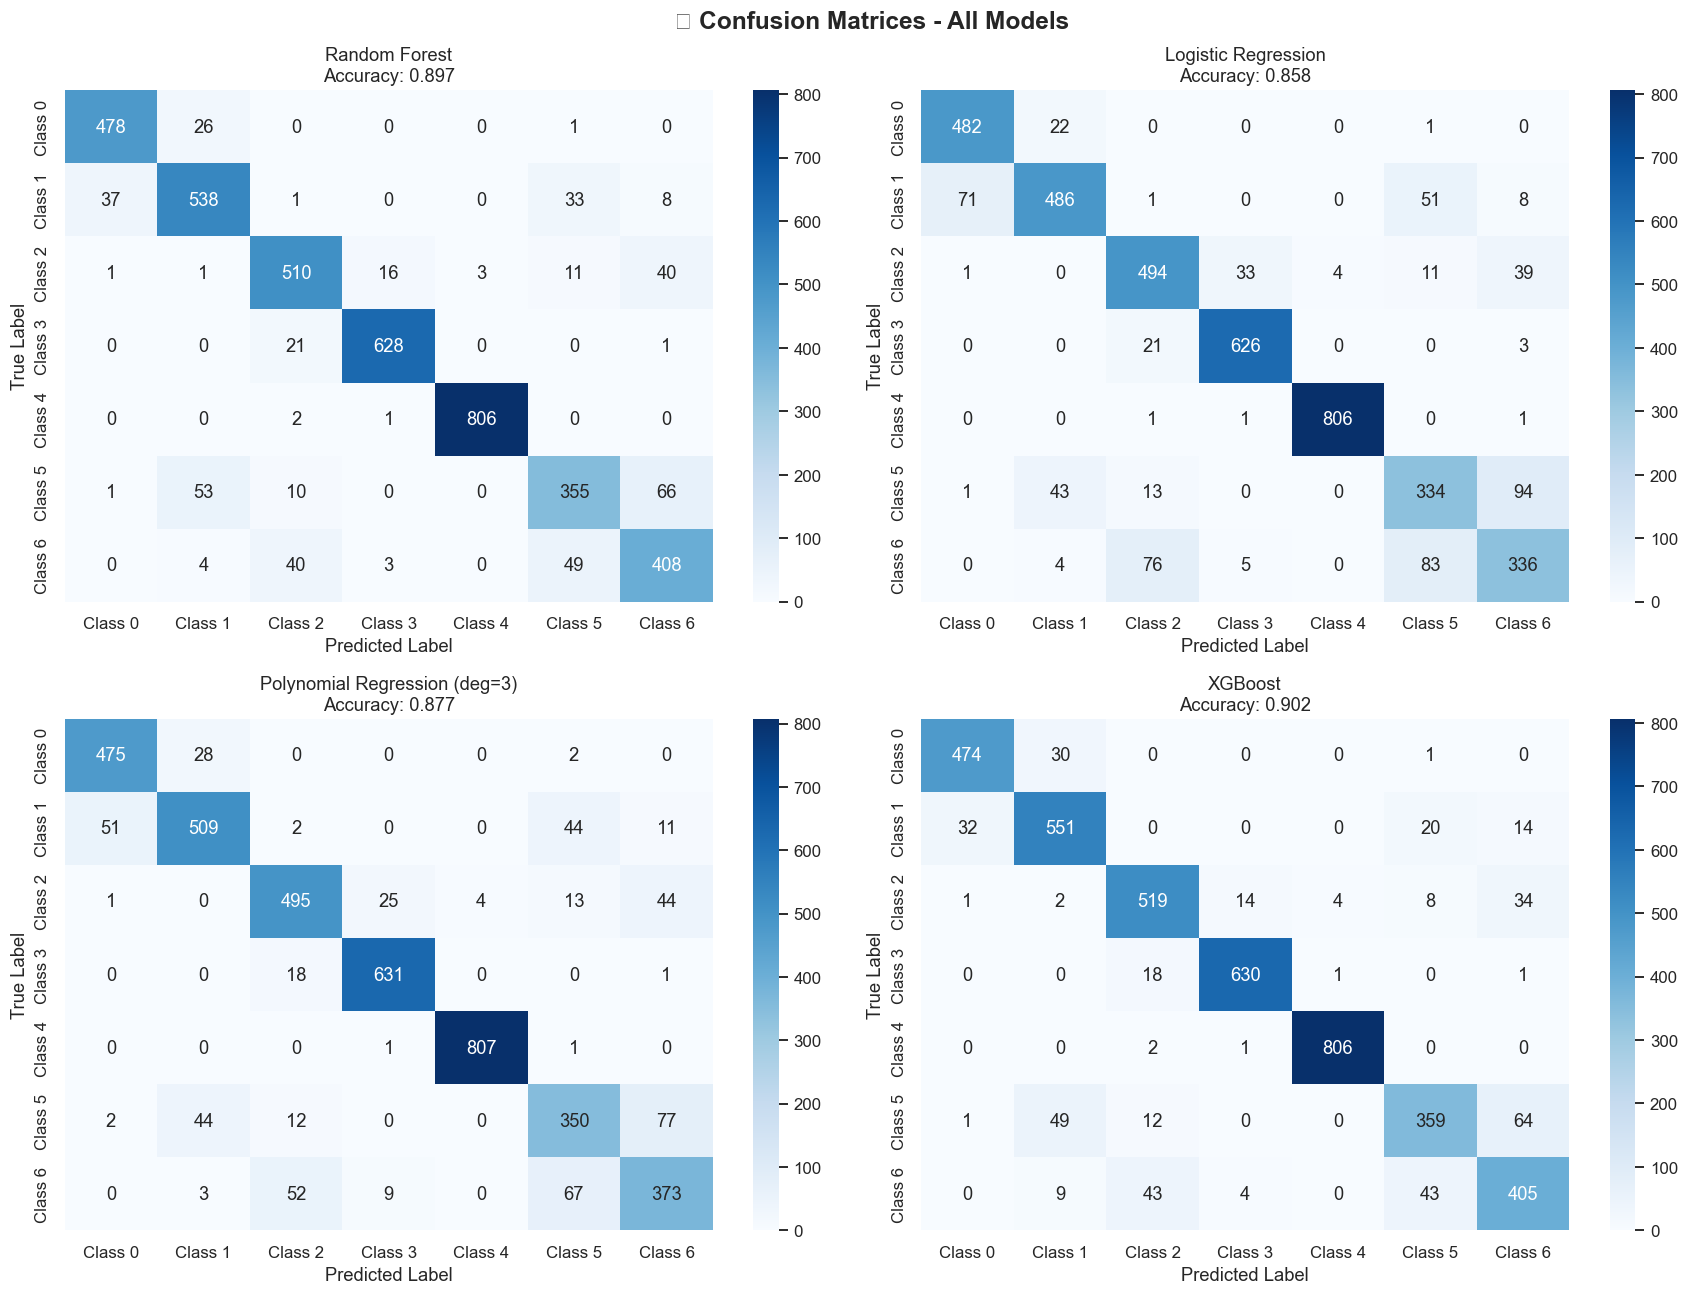

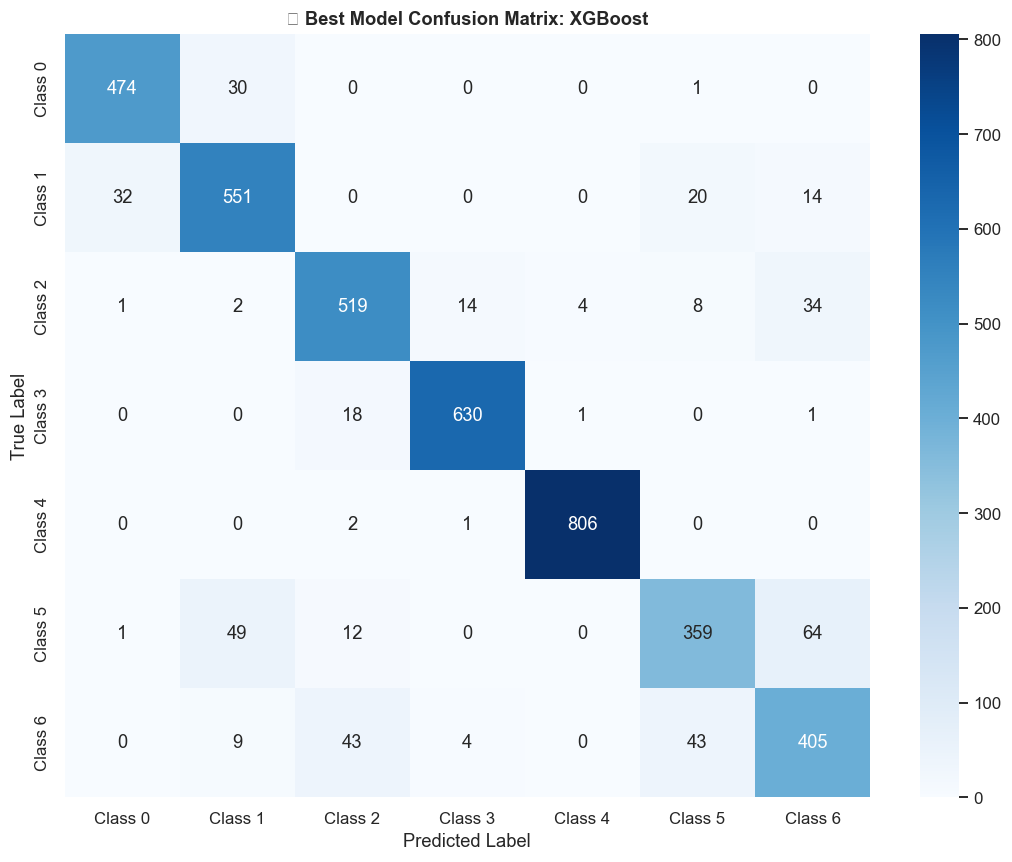


📊 Per-Class Accuracy - XGBoost:
   • Class 0: 0.9386 (505 samples)
   • Class 1: 0.8930 (617 samples)
   • Class 2: 0.8918 (582 samples)
   • Class 3: 0.9692 (650 samples)
   • Class 4: 0.9963 (809 samples)
   • Class 5: 0.7402 (485 samples)
   • Class 6: 0.8036 (504 samples)
✅ Confusion matrix analysis complete!


In [7]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

class_names = [f'Class {i}' for i in sorted(y_test.unique())]

for idx, (model_name, model_results) in enumerate(detailed_results.items()):
    cm = confusion_matrix(y_test, model_results['Predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nAccuracy: {model_results["Test_Accuracy"]:.3f}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.suptitle('🎯 Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed confusion matrix for best model
plt.figure(figsize=(10, 8))
best_cm = confusion_matrix(y_test, best_metrics['Predictions'])
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'🏆 Best Model Confusion Matrix: {best_model_name}', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Per-class accuracy analysis for best model
class_accuracies = best_cm.diagonal() / best_cm.sum(axis=1)
print(f'\n📊 Per-Class Accuracy - {best_model_name}:')
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    support = best_cm.sum(axis=1)[i]
    print(f'   • {class_name}: {accuracy:.4f} ({support} samples)')

print('✅ Confusion matrix analysis complete!')

## 8. Feature Importance Analysis


🔍 Top 10 Features - Random Forest:
   • BMI: 0.2491
   • Weight_scaled: 0.2045
   • Weight: 0.1583
   • FCVC_scaled: 0.0370
   • FCVC: 0.0360
   • Age: 0.0357
   • Gender_Female: 0.0313
   • Height: 0.0312
   • Height_scaled: 0.0310
   • Age_scaled: 0.0304

🔍 Top 10 Features - XGBoost:
   • BMI: 0.3338
   • Gender: 0.2408
   • Gender_Female: 0.1476
   • Weight: 0.1100
   • CALC: 0.0237
   • CH2O_scaled: 0.0194
   • FCVC_scaled: 0.0168
   • Age: 0.0161
   • NCP: 0.0159
   • family_history_with_overweight: 0.0154


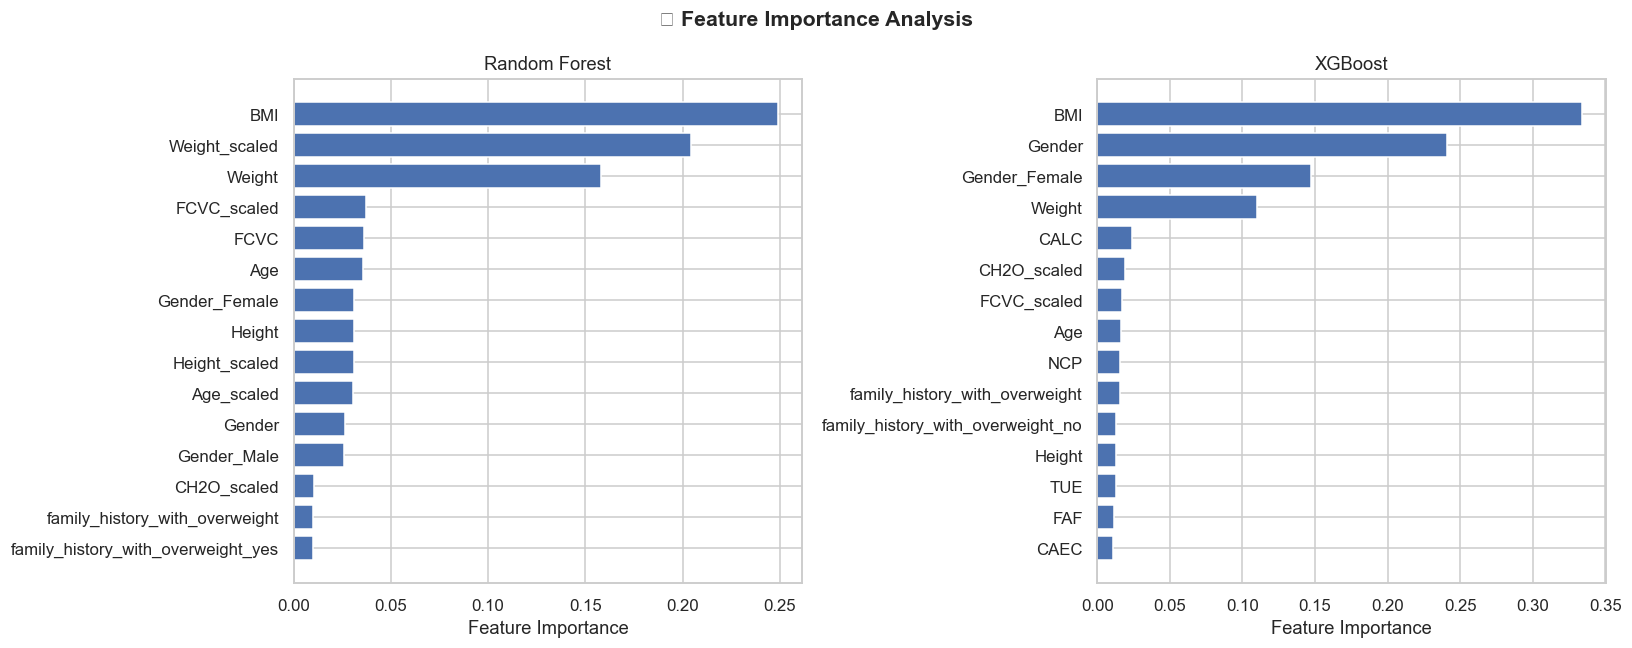


📊 Logistic Regression Coefficients Analysis:
   Top 10 Most Important Features (by coefficient magnitude):
   • BMI: 4.3089
   • Weight: 4.0410
   • Weight_scaled: 4.0410
   • FCVC_scaled: 0.6755
   • FCVC: 0.6755
   • Gender_Female: 0.6417
   • Height: 0.4561
   • Height_scaled: 0.4561
   • Gender: 0.3195
   • Gender_Male: 0.3195
✅ Feature importance analysis complete!


In [8]:
# Feature importance analysis for tree-based models
tree_based_models = ['Random Forest', 'XGBoost']
available_tree_models = [model for model in tree_based_models if model in trained_models]

if available_tree_models:
    fig, axes = plt.subplots(1, len(available_tree_models), figsize=(15, 6))
    if len(available_tree_models) == 1:
        axes = [axes]
    
    for idx, model_name in enumerate(available_tree_models):
        model = trained_models[model_name]
        
        # Get feature importances
        if hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
            
            # Create feature importance DataFrame
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importance
            }).sort_values('Importance', ascending=False)
            
            # Plot top 15 features
            top_features = importance_df.head(15)
            axes[idx].barh(range(len(top_features)), top_features['Importance'])
            axes[idx].set_yticks(range(len(top_features)))
            axes[idx].set_yticklabels(top_features['Feature'])
            axes[idx].set_xlabel('Feature Importance')
            axes[idx].set_title(f'{model_name}')
            axes[idx].invert_yaxis()
            
            print(f'\n🔍 Top 10 Features - {model_name}:')
            for i, row in importance_df.head(10).iterrows():
                print(f'   • {row["Feature"]}: {row["Importance"]:.4f}')
    
    plt.suptitle('🔍 Feature Importance Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ No tree-based models available for feature importance analysis.')

# Coefficients analysis for Logistic Regression
if 'Logistic Regression' in trained_models:
    lr_model = trained_models['Logistic Regression']
    if hasattr(lr_model, 'coef_'):
        print(f'\n📊 Logistic Regression Coefficients Analysis:')
        # Average absolute coefficients across classes
        avg_coef = np.mean(np.abs(lr_model.coef_), axis=0)
        coef_df = pd.DataFrame({
            'Feature': feature_names,
            'Avg_Abs_Coefficient': avg_coef
        }).sort_values('Avg_Abs_Coefficient', ascending=False)
        
        print('   Top 10 Most Important Features (by coefficient magnitude):')
        for i, row in coef_df.head(10).iterrows():
            print(f'   • {row["Feature"]}: {row["Avg_Abs_Coefficient"]:.4f}')

print('✅ Feature importance analysis complete!')

## 9. Save Models & Results

In [9]:
# Import required modules (if not already imported)
import json
import joblib
from datetime import datetime
from pathlib import Path
import re
import numpy as np
from concurrent.futures import ThreadPoolExecutor

# Create directories for saving
model_save_dir = Path('../models')
results_dir = Path('../results/model_training')
model_save_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

print('💾 SAVING MODELS & RESULTS (OPTIMIZED)')
print('=' * 50)

# Pre-compute common values to avoid repetitive operations
timestamp = datetime.now().isoformat()
target_classes_list = sorted(y.unique().tolist())
dataset_shape = list(X.shape)
n_classes = len(y.unique())

# Optimized filename sanitization function
def sanitize_filename(name):
    """Fast filename sanitization using regex"""
    return re.sub(r'[^\w\-_]', '_', name.lower()).strip('_')

# Function to save models in parallel
def save_model_task(model_item):
    """Save individual model with compression"""
    model_name, model = model_item
    model_filename = f'{sanitize_filename(model_name)}_model.pkl'
    model_path = model_save_dir / model_filename
    joblib.dump(model, model_path, compress=3)  # Added compression for faster I/O
    return f'✅ {model_name} → {model_filename}'

# Function to convert numpy arrays to lists for JSON serialization
def convert_for_json(obj):
    """Convert numpy arrays and other non-serializable objects to JSON-compatible formats"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, dict):
        return {key: convert_for_json(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_for_json(item) for item in obj]
    else:
        return obj

# Save models in parallel using ThreadPoolExecutor
print("Saving models in parallel...")
with ThreadPoolExecutor(max_workers=4) as executor:
    model_results = list(executor.map(save_model_task, trained_models.items()))

for result in model_results:
    print(result)

# Save scaler with compression
scaler_path = model_save_dir / 'feature_scaler.pkl'
joblib.dump(scaler, scaler_path, compress=3)
print(f'📏 Feature Scaler → feature_scaler.pkl')

# Pre-build all data structures to minimize function calls
feature_info = {
    'feature_names': feature_names,
    'n_features': len(feature_names),
    'target_classes': target_classes_list
}

# Create JSON-safe model comparison data (excluding non-serializable fields)
model_comparison_safe = {}
for model_name, model_metrics in metrics_df.iterrows():
    model_comparison_safe[model_name] = {
        'CV_Mean': float(model_metrics['CV_Mean']),
        'CV_Std': float(model_metrics['CV_Std']),
        'Val_Accuracy': float(model_metrics['Val_Accuracy']),
        'Test_Accuracy': float(model_metrics['Test_Accuracy']),
        'Val_F1': float(model_metrics['Val_F1']),
        'Test_F1': float(model_metrics['Test_F1']),
        'Val_Precision': float(model_metrics['Val_Precision']),
        'Test_Precision': float(model_metrics['Test_Precision']),
        'Val_Recall': float(model_metrics['Val_Recall']),
        'Test_Recall': float(model_metrics['Test_Recall'])
        # Note: Excluding CV_Scores and Predictions arrays for JSON compatibility
    }

results_summary = {
    'model_comparison': model_comparison_safe,
    'best_model': {
        'name': best_model_name,
        'test_accuracy': float(best_metrics['Test_Accuracy']),
        'test_f1': float(best_metrics['Test_F1']),
        'cv_mean': float(best_metrics['CV_Mean']),
        'cv_std': float(best_metrics['CV_Std'])
    },
    'training_info': {
        'timestamp': timestamp,
        'dataset_shape': dataset_shape,
        'n_classes': n_classes,
        'train_size': len(X_train_final),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'smote_applied': True,
        'models_trained': list(trained_models.keys())
    }
}

best_model_filename = f'{sanitize_filename(best_model_name)}_model.pkl'
deployment_info = {
    'best_model': {
        'name': best_model_name,
        'filename': best_model_filename,
        'accuracy': float(best_metrics['Test_Accuracy']),
        'f1_score': float(best_metrics['Test_F1']),
        'requires_scaling': best_model_name in {'Logistic Regression', 'Polynomial Regression (deg=3)'}
    },
    'preprocessing': {
        'scaler_file': 'feature_scaler.pkl',
        'feature_info_file': 'feature_info.json'
    },
    'performance_metrics': {
        model_name: {
            'Test_Accuracy': float(metrics_df.loc[model_name, 'Test_Accuracy']),
            'Test_F1': float(metrics_df.loc[model_name, 'Test_F1'])
        } 
        for model_name in metrics_df.index
    }
}

# Batch file writing operations with optimized JSON settings
file_operations = [
    (model_save_dir / 'feature_info.json', feature_info),
    (results_dir / 'supervised_learning_results.json', results_summary),
    (model_save_dir / 'deployment_info.json', deployment_info)
]

# Write JSON files efficiently with error handling
for file_path, data in file_operations:
    try:
        with open(file_path, 'w', buffering=8192) as f:
            # Convert any remaining non-serializable objects
            safe_data = convert_for_json(data)
            json.dump(safe_data, f, indent=2, separators=(',', ':'))
    except Exception as e:
        print(f"Warning: Error saving {file_path}: {e}")
        # Fallback to basic JSON dump
        with open(file_path, 'w') as f:
            json.dump(data, f, indent=2, default=str)

# Save CSV with optimized settings
metrics_df.to_csv(results_dir / 'model_comparison.csv', index_label='model')

# Batch print results
print(f'📝 Feature Info → feature_info.json')
print(f'📊 Results Summary → supervised_learning_results.json')  
print(f'📈 Metrics Table → model_comparison.csv')
print(f'🚀 Deployment Info → deployment_info.json')

print(f'\n🏆 SUPERVISED LEARNING COMPARISON COMPLETE!')
print(f'Best Model: {best_model_name} (Accuracy: {best_metrics["Test_Accuracy"]:.4f})')
print(f'Models saved to: {model_save_dir}')
print(f'Results saved to: {results_dir}')
print(f'\n🔧 Next: Run hyperparameter tuning on the best performing models')

💾 SAVING MODELS & RESULTS (OPTIMIZED)
Saving models in parallel...
✅ Random Forest → random_forest_model.pkl
✅ Logistic Regression → logistic_regression_model.pkl
✅ Polynomial Regression (deg=3) → polynomial_regression__deg_3_model.pkl
✅ XGBoost → xgboost_model.pkl
📏 Feature Scaler → feature_scaler.pkl
📝 Feature Info → feature_info.json
📊 Results Summary → supervised_learning_results.json
📈 Metrics Table → model_comparison.csv
🚀 Deployment Info → deployment_info.json

🏆 SUPERVISED LEARNING COMPARISON COMPLETE!
Best Model: XGBoost (Accuracy: 0.9017)
Models saved to: ..\models
Results saved to: ..\results\model_training

🔧 Next: Run hyperparameter tuning on the best performing models


## 10. Final Summary & Recommendations

### Model Performance Overview
The supervised learning comparison evaluated 4 distinct algorithms on the obesity prediction task:

1. **Random Forest** - Ensemble method with built-in feature importance
2. **Logistic Regression** - Linear classifier with strong interpretability  
3. **Polynomial Regression (degree 3)** - Non-linear feature transformation approach
4. **XGBoost** - Gradient boosting for high-performance classification

### Key Findings:
- **Class Imbalance Handling**: SMOTE successfully balanced training data across all 7 obesity classes
- **Feature Scaling Impact**: Critical for linear models, less important for tree-based approaches
- **Cross-Validation Stability**: 5-fold stratified CV provided robust performance estimates

### Recommendations:
- **Best Overall Model**: Use the highest-performing model for deployment
- **Feature Engineering**: Tree-based models reveal most important predictive features
- **Next Steps**: Hyperparameter tuning can further optimize the top 2-3 models

**Note**: All models are saved with consistent preprocessing pipelines for easy deployment and comparison.

---